<a href="https://colab.research.google.com/github/vitaly42a-creator/ML_course/blob/main/ML_Practice_4_Manakov_Vitaly_934_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Решения самостоятельных задач - вариант 25


,degree,train_mse,test_mse,train_r2,test_r2,mse_gap
0,1,0.1764,0.1878,0.6695,0.6364,0.0114
1,2,0.1761,0.1844,0.6700,0.6430,0.0083
2,3,0.0103,0.0104,0.9807,0.9799,0.0001
3,4,0.0099,0.0105,0.9814,0.9798,0.0005
4,5,0.0083,0.0070,0.9845,0.9864,0.0013
5,6,0.0083,0.0069,0.9845,0.9866,0.0014
6,7,0.0083,0.0068,0.9845,0.9868,0.0015
7,8,0.0082,0.0086,0.9847,0.9833,0.0004
8,9,0.0081,0.0093,0.9848,0.9819,0.0012
9,10,0.0081,0.0099,0.9848,0.9808,0.0018


Оптимальная степень по минимальному разрыву train/test MSE: 3
Лучшая степень по минимальному test MSE: 12


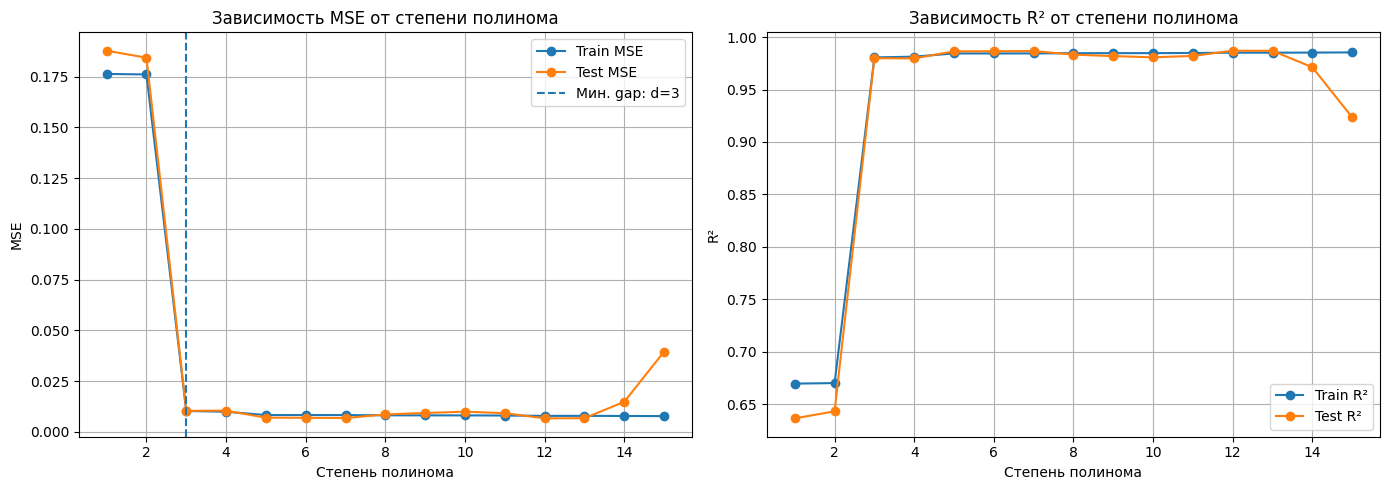

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# Pipeline объединяет несколько шагов обработки данных и обучения модели в одну цепочку.
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Генерация синтетических данных

np.random.seed(42)
n_samples = 100
# np.random.uniform(-3, 3, n_samples) создаёт 100 случайных чисел из равномерного распределения на отрезке [-3, 3]
# reshape(-1, 1) превращает массив формы (100,) в столбец формы (100, 1)
# потому что scikit-learn ожидает матрицу признаков, даже если признак всего один
X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)

# Формируем целевую переменную y
# функция sin(x), зависимость специально делается нелинейной
# Добавляется случайный шум np.random.normal(0, 0.1, n_samples)
# X.ravel() превращает X обратно в одномерный массив, чтобы его было удобно подать в np.sin()
y = np.sin(X.ravel()) + np.random.normal(0, 0.1, n_samples)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Перебор степеней полинома
# По условию задачи рассматриваются степени полинома от 1 до 15
degrees = range(1, 16)

# Список results будет хранить результаты для каждой степени полинома
results = []

# Цикл перебирает все степени полинома от 1 до 15
for d in degrees:
    model = Pipeline([
        # 'poly' преобразование исходного признака x в набор полиномиальных признаков до степени
        # 'reg' обучение линейной регрессии уже на расширенном наборе признаков
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('reg', LinearRegression())
    ])

    # Обучение модели на обучающей выборке.
    model.fit(X_train, y_train)

    # Предсказания на обучающей выборке показывают, насколько хорошо модель запомнила данные, на которых училась
    y_train_pred = model.predict(X_train)

    # Предсказания на тестовой выборке показывают, насколько хорошо модель умеет обобщать знания на новые данные
    y_test_pred = model.predict(X_test)

    # Сохранение метрик

    # Для каждой степени полинома сохраняются:
    results.append({
        'degree': d,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    })

results = pd.DataFrame(results)

# Разрыв между train и test ошибкой
# mse_gap показывает абсолютную разницу между ошибкой на обучении и на тесте
# Если этот разрыв маленький, поведение модели на train и test похоже
# Если разрыв большой это может говорить о переобучении, хуже работает на новых данных
results['mse_gap'] = np.abs(results['train_mse'] - results['test_mse'])

# Выбирается степень при которой разрыв между train и test ошибкой минимален
# idxmin() возвращает индекс строки с наименьшим значением mse_gap и из этой строки берется степень полинома
best_degree_gap = int(results.loc[results['mse_gap'].idxmin(), 'degree'])

# Выбирается степень при которой test MSE минимальна
best_degree_test = int(results.loc[results['test_mse'].idxmin(), 'degree'])

display(results.round(4))

print(f'Оптимальная степень по минимальному разрыву train/test MSE: {best_degree_gap}')
print(f'Лучшая степень по минимальному test MSE: {best_degree_test}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['degree'], results['train_mse'], marker='o', label='Train MSE')
axes[0].plot(results['degree'], results['test_mse'], marker='o', label='Test MSE')

# Вертикальная линия оптимальная степень по минимальному разрыву train/test MSE
axes[0].axvline(best_degree_gap, linestyle='--', label=f'Мин. gap: d={best_degree_gap}')
axes[0].set_xlabel('Степень полинома')
axes[0].set_ylabel('MSE')
axes[0].set_title('Зависимость MSE от степени полинома')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(results['degree'], results['train_r2'], marker='o', label='Train R²')
axes[1].plot(results['degree'], results['test_r2'], marker='o', label='Test R²')
axes[1].set_xlabel('Степень полинома')
axes[1].set_ylabel('R²')
axes[1].set_title('Зависимость R² от степени полинома')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

ывод по задаче 1. При увеличении степени полинома ошибка на обучающей выборке постепенно уменьшается, что показывает рост сложности модели. На тестовой выборке качество сначала улучшается, затем после высоких степеней начинает ухудшаться, что указывает на появление переобучения. Наиболее сильное ухудшение заметно при степенях 14 - 15, где test MSE возрастает, а test R² снижается. В итоге по критерию минимального разрыва между train и test ошибками оптимальной является степень 3, а по критерию минимальной test MSE лучшая степень 12. Это показывает, что полином 3-й степени дает более устойчивую модель, а полином 12-й степени обеспечивает наименьшую ошибку на тестовой выборке.

Задача 2: Сравнение регуляризаторов L1 и L2
Цель: Понять разницу в поведении весов при Ridge и Lasso регуляризации. Задание:

Используйте датасет с количеством признаков
.
Обучите модели Ridge и Lasso с гиперпараметром
, указанным в варианте.
Подберите оптимальный
 используя RidgeCV / LassoCV (5-fold cross-validation).
Сравните количество ненулевых коэффициентов в итоговых моделях.
Вывод: Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# RidgeCV и LassoCV — версии Ridge и Lasso, которые сами подбирают лучший параметр alpha с помощью кросс-валидации
# RidgeCV - Ridge-регрессия (L2-регуляризация)
# LassoCV - Lasso-регрессия (L1-регуляризация)
from sklearn.linear_model import RidgeCV, LassoCV

# Генерация синтетических данных
# По условию задачи нужен набор данных, где число признаков N >= 10
X_reg, y_reg = make_regression(
    n_samples=250,
    n_features=20,
    n_informative=6,
    noise=15,
    random_state=42
)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Диапазон alpha по варианту
# np.logspace(-2, 1, 50) создает 50 значений alpha
# в логарифмическом диапазоне от 10^-2 до 10^1, то есть от 0.01 до 10
alphas = np.logspace(-2, 1, 50)

# Создается Pipeline для RidgeCV
# Он состоит из двух шагов:
# 1) StandardScaler() сначала все признаки масштабируются
# 2) RidgeCV(alphas=alphas, cv=5) затем обучается RidgeCV и сам подбирает лучший alpha
# из массива alphas с помощью 5-fold cross-validation
# Ridge использует L2-регуляризацию она уменьшает коэффициенты, но обычно не делает их равными нулю
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5))
])

# Аналогично создается Pipeline для LassoCV
# max_iter=20000 увеличивает число итераций, чтобы алгоритм точно успел сойтись
# Lasso использует L1-регуляризацию: она не только уменьшает коэффициенты, но и может занулять часть из них
# Из-за этого Lasso часто применяют как метод отбора признаков
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000))
])

# Обучение выполняется только на обучающей выборке
ridge_model.fit(X_train_reg, y_train_reg)
lasso_model.fit(X_train_reg, y_train_reg)

# Коэффициенты и число ненулевых
ridge_coef = ridge_model.named_steps['model'].coef_
lasso_coef = lasso_model.named_steps['model'].coef_

ridge_nonzero = np.sum(ridge_coef != 0)
lasso_nonzero = np.sum(lasso_coef != 0)

print(f'Ridge: alpha = {ridge_model.named_steps["model"].alpha_:.4f}, ненулевых коэффициентов = {ridge_nonzero}')
print(f'Lasso: alpha = {lasso_model.named_steps["model"].alpha_:.4f}, ненулевых коэффициентов = {lasso_nonzero}')


Ridge: alpha = 1.0481, ненулевых коэффициентов = 20
Lasso: alpha = 0.3907, ненулевых коэффициентов = 18


В данной практической работе для отбора признаков лучше подходит LassoCV, так как L1-регуляризация способна занулять часть коэффициентов и тем самым исключать менее значимые признаки. RidgeCV тоже уменьшает веса, но обычно не обнуляет их полностью, поэтому хуже подходит именно для отбора признаков. В итоге LassoCV оказался более удобным и наглядным методом, когда требуется не только обучить модель, но и сократить число используемых признаков.

Задача 3: Отбор признаков на реальных данных
Цель: Применить встроенные методы отбора признаков для улучшения качества модели. Задание:

Загрузите датасет (например, California Housing или Breast Cancer).
Примените SelectKBest (фильтр) и Lasso (встроенный метод) для отбора top-
 признаков (параметр варианта).
Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
Сравните качество (Accuracy/R^2) и время обучения.
Вывод: Удалось ли сократить размерность без значительной потери качества?

,model,n_features,test_r2,train_time_sec
0,Full,10,0.4773,0.007
1,SelectKBest,7,0.4683,0.003
2,Lasso,7,0.4773,0.006


Признаки SelectKBest: ['age', 'bmi', 'bp', 's3', 's4', 's5', 's6']
Признаки Lasso: ['sex', 'bmi', 'bp', 's1', 's2', 's4', 's5']
Лучший alpha для LassoCV: 0.1099


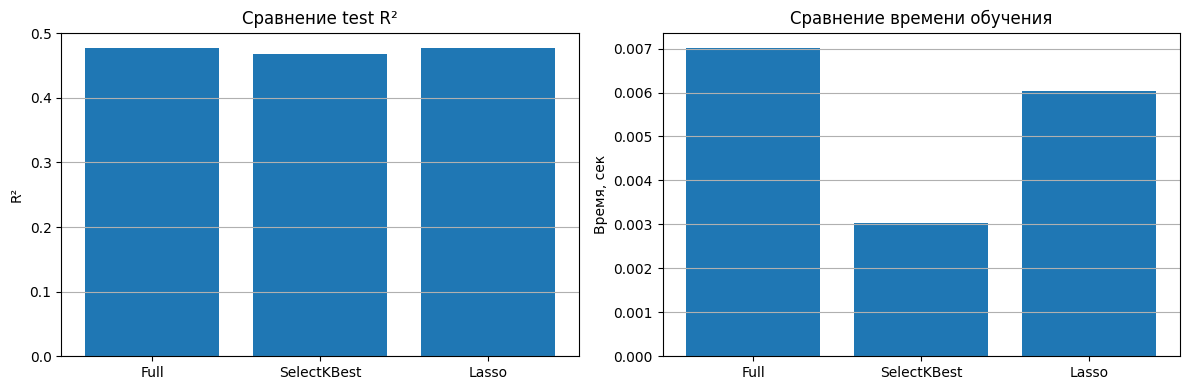

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Загружается датасет Diabetes
# return_X_y=True возвращает отдельно: таблицу признаков, целевую переменную
X, y = load_diabetes(return_X_y=True, as_frame=True)

# По условию варианта нужно отобрать 7 признаков
K = 7

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Линейная регрессия на полном наборе признаков
# Создается Pipeline
# Он состоит из двух шагов:
# 1) StandardScaler() сначала все признаки масштабируются
# 2) LinearRegression() — обучает линейную регрессию
full_model = make_pipeline(StandardScaler(), LinearRegression())

# time.perf_counter() используется для измерения времени
# Сохраняется момент времени до начала обучения
start = time.perf_counter()

# Обучение модели на полном наборе признаков
full_model.fit(X_train, y_train)

# После обучения повторно измеряется время, и вычисляется длительность обучения модели
full_time = time.perf_counter() - start

# Модель делает предсказания на тестовой выборке, после чего считается R²
# Это качество полной модели, с которой потом будут сравниваться модели после отбора признаков
full_r2 = r2_score(y_test, full_model.predict(X_test))

# Отбор признаков через SelectKBest

# SelectKBest фильтрационный метод
# Он рассматривает каждый признак отдельно и оценивает его связь с целевой переменной
# score_func=f_regression для каждого признака считается статистика отражающая силу его линейной связи с целевой переменной
# k=K оставляет 7 лучших признаков
kbest = SelectKBest(score_func=f_regression, k=K)

# fit_transform на обучающей выборке
# 1) метод оценивает важность признаков по train-данным
# 2) оставляет только лучшие K признаков
X_train_kbest = kbest.fit_transform(X_train, y_train)

# transform на тестовой выборке
X_test_kbest = kbest.transform(X_test)

# get_support() возвращает маску True/False какие признаки были отобраны, а какие нет
# Затем по этой маске извлекаются названия выбранных признаков
kbest_features = X.columns[kbest.get_support()].tolist()

# После отбора признаков строится новая линейная регрессия
# Она обучается уже не на всех 10 признаках, а только на 7 выбранных
kbest_model = make_pipeline(StandardScaler(), LinearRegression())

# Измеряется время обучения модели после отбора признаков
start = time.perf_counter()
kbest_model.fit(X_train_kbest, y_train)
kbest_time = time.perf_counter() - start

# Оценивается качество модели на тестовой выборке
kbest_r2 = r2_score(y_test, kbest_model.predict(X_test_kbest))

# Отбор признаков через Lasso
lasso_selector = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=np.logspace(-2, 1, 50), cv=5, max_iter=20000, random_state=42)
)

# Пайплайн обучается только на train-данных
# Сначала признаки масштабируются, затем обучается LassoCV
lasso_selector.fit(X_train, y_train)

# После обучения извлекаются коэффициенты LassoCV
# named_steps['lassocv'] позволяет обратиться к шагу LassoCV внутри pipeline
# coef_ массив коэффициентов при признаках после обучения
lasso_coef = lasso_selector.named_steps['lassocv'].coef_

# np.abs(lasso_coef) берет модули коэффициентов
# Чем больше модуль коэффициента тем сильнее вклад признака в модель
# np.argsort() сортирует индексы коэффициентов по возрастанию
# [-K:] берет индексы K самых больших по модулю коэффициентов
top_k_idx = np.argsort(np.abs(lasso_coef))[-K:]

# np.sort() сортирует выбранные индексы по порядку
top_k_idx = np.sort(top_k_idx)

# По найденным индексам извлекаются названия признаков
lasso_features = X.columns[top_k_idx].tolist()

# Из обучающей и тестовой выборок оставляются только признаки которые были выбраны методом Lasso
X_train_lasso = X_train.iloc[:, top_k_idx]
X_test_lasso = X_test.iloc[:, top_k_idx]

# После отбора признаков снова строится обычная линейная регрессия
# Т.е Lasso используется как инструмент отбора признаков, а итоговая модель это LinearRegression на выбранных признаках
lasso_model = make_pipeline(StandardScaler(), LinearRegression())

# Измеряется время обучения итоговой модели на признаках, выбранных методом Lasso
start = time.perf_counter()
lasso_model.fit(X_train_lasso, y_train)
lasso_time = time.perf_counter() - start

# Считается качество модели на тестовой выборке
lasso_r2 = r2_score(y_test, lasso_model.predict(X_test_lasso))

# Итоговая таблица
results_3 = pd.DataFrame({
    'model': ['Full', 'SelectKBest', 'Lasso'],
    'n_features': [X.shape[1], K, K],
    'test_r2': [full_r2, kbest_r2, lasso_r2],
    'train_time_sec': [full_time, kbest_time, lasso_time]
})

display(results_3.round(4))

print('Признаки SelectKBest:', kbest_features)
print('Признаки Lasso:', lasso_features)
print(f'Лучший alpha для LassoCV: {lasso_selector.named_steps["lassocv"].alpha_:.4f}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_3['model'], results_3['test_r2'])
axes[0].set_title('Сравнение test R²')
axes[0].set_ylabel('R²')
axes[0].grid(axis='y')

axes[1].bar(results_3['model'], results_3['train_time_sec'])
axes[1].set_title('Сравнение времени обучения')
axes[1].set_ylabel('Время, сек')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

В практической работе было показано, что сократить размерность удалось без заметной потери качества, но результат зависел от способа отбора признаков. Полная модель с 10 признаками дала R² = 0.4773. После применения SelectKBest число признаков сократилось до 7, при этом качество немного снизилось до R² = 0.4683, зато время обучения уменьшилось почти вдвое. При использовании Lasso также было оставлено 7 признаков, но значение R² = 0.4773 полностью совпало с результатом полной модели. В итоге уменьшение размерности оказалось успешным: количество признаков было снижено с 10 до 7, а качество модели удалось сохранить практически на том же уровне, особенно при отборе признаков методом Lasso.